### The notebook is for diff types of classification trees.

In [17]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(rpart.plot)  # plotting regression trees
library(ipred)       # bagging
library(caret)       # bagging
library(smotefamily)
library(janitor) 
library(readr)
library(tidyverse)
library(caret)
library(xgboost)
library(rPref)
library(ggplot2)
library(igraph)

Warning message:
"Paket 'rPref' wurde unter R Version 4.4.1 erstellt"

Attache Paket: 'rPref'


Das folgende Objekt ist maskiert 'package:dplyr':

    between


Warning message:
"Paket 'igraph' wurde unter R Version 4.4.3 erstellt"

Attache Paket: 'igraph'


Die folgenden Objekte sind maskiert von 'package:lubridate':

    %--%, union


Die folgenden Objekte sind maskiert von 'package:purrr':

    compose, simplify


Das folgende Objekt ist maskiert 'package:tidyr':

    crossing


Das folgende Objekt ist maskiert 'package:tibble':

    as_data_frame


Die folgenden Objekte sind maskiert von 'package:dplyr':

    as_data_frame, groups, union


Die folgenden Objekte sind maskiert von 'package:stats':

    decompose, spectrum


Das folgende Objekt ist maskiert 'package:base':

    union




We set some global parmeter for the tree model.

In [3]:
# DATA RELATED PARAMS
def_outbreak = 2 # number of cases to be considered as outbreak
perc_strata = 0.75 # proportion of data to be used for training
# SMOTE RELATED PARAMS
K_neighbors = 5 # number of nearest neighbors
Ratio_testtrain = 0 # for 50/50 outbreak/non-outbreak

#### THIS SECTION IS FOR PREPARING DATA

The following code block is for loading the data and splitting it into training and testing sets. This is done with createDataPartition to ensure approx same distribution and we assume a place with outbreak has to have more than 2 cases.

In [4]:
set.seed(100)

df <- read_csv("data/merged_data.csv") |> clean_names() 

# outbreak >=2 is with outbreak, vice versa.
df$outbreak <- as.integer(df$outbreak >= def_outbreak)

# split the data with stratified sampling
strata <- ifelse(df$outbreak > 0, "nonzero", "zero")
index <- createDataPartition(strata, p = perc_strata, list = FALSE)
train <- df[index,]
test <- df[-index,]
head(train)

Rows: 254 Columns: 405
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (1): County
dbl (381): cve, outbreak, enrollment, population, PHR, pct_hispanic, pct_bla...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in FUN(X[[i]], ...):
"kann '<U+00C4>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00D6>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00DC>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00E4>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00F6>' nicht in native Kodierung "ubersetzen"
Warning message in FUN(X[[i]], ...):
"kann '<U+00FC>' nicht in native Kodierung "ub

county,cve,outbreak,enrollment,population,phr,pct_hispanic,pct_black,pct_white,pct_poverty,...,up_to_date_cervical_cancer_s_no,up_to_date_cervical_cancer_s_yes,up_to_date_cervical_cancer_s_2_no,up_to_date_cervical_cancer_s_2_yes,v_col_5_yrs_50_75_ia_no,v_col_5_yrs_50_75_ia_yes,v_col_5_yrs_age_50_75_no,v_col_5_yrs_age_50_75_yes,virtual_colonoscopy_no,virtual_colonoscopy_yes
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Anderson,2.54,0,7808,60303,4,19.6,18.6,58.3,13.5,...,NA,NA,NA,NA,92.8,NA,92.8,NA,72.4,NA
Angelina,2.50,0,15649,87492,5,23.5,12.1,63.4,11.5,...,36.9,63.1,36.8,63.2,92.2,NA,92.3,NA,65.5,34.5
Armstrong,5.24,0,297,1806,1,12.0,0.6,89.9,6.0,...,39.9,60.1,40.0,60.0,96.9,NA,96.9,NA,76.0,NA
Austin,3.55,0,6290,32958,6,27.8,7.9,66.6,10.6,...,39.2,60.8,39.1,60.9,97.0,NA,97.0,NA,74.3,25.7
Bailey,0.80,1,1330,7057,1,66.0,0.9,71.3,7.4,...,39.9,60.1,40.0,60.0,96.9,NA,96.9,NA,76.0,NA
Bandera,3.78,0,2461,22918,8,21.0,1.2,77.2,8.5,...,28.4,71.6,28.3,71.7,96.4,NA,96.3,NA,80.6,19.4


SMOTE function only takes in numeric data and unfortunately removing all NAs by row will remove all the counties. This code block is for pleasing SMOTE to work. We first remove county col as it is the only one with str, and then we remove all cols containing any flavor of NAs.

In [5]:
train <- train[, colSums(is.na(train)) == 0]
train <- train[, !names(train) %in% c("county")]

This code block is for creating artificial data for training using SMOTE method (fundamentally introducing noise) and balancing between the two class.

In [6]:
set.seed(42)
# K for controlling the neighborhood, dup_size for ratio to achieve
smote_output <- SMOTE(
  X      = train[, names(train) != "outbreak"],
  target = train$outbreak,
  K      = K_neighbors, 
  dup_size = Ratio_testtrain
)

train_balanced <- smote_output$data
# SMOTE put target data in "class" col and rename it
names(train_balanced)[names(train_balanced) == "class"] <- "outbreak"
train_balanced$outbreak <- as.factor(train_balanced$outbreak)
cat("\nClass balance after SMOTE:\n")
print(table(train_balanced$outbreak))
head(train_balanced)
# mirror on test set
test <- test[, colSums(is.na(test)) == 0]
test <- test[, !names(test) %in% c("county")]
test$outbreak <- as.factor(test$outbreak)


Class balance after SMOTE:

  0   1 
174 162 


cve,population,phr,pct_hispanic,pct_black,pct_white,pct_poverty,pct_uninsured,pct_college,pct_foreign_born,...,teeth_removed_no,teeth_removed_yes,up_to_date_crc_scrn_50_75_ia_no,up_to_date_crc_scrn_50_75_ia_yes,up_to_date_crc_scrn_age_50_7_no,up_to_date_crc_scrn_age_50_7_yes,v_col_5_yrs_50_75_ia_no,v_col_5_yrs_age_50_75_no,virtual_colonoscopy_no,outbreak
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1.88,15034,9,85.3,1.8,38.8,13.3,17.5,7.4,1.6,...,60.4,39.6,37.6,62.4,37.6,62.4,92.8,92.8,72.2,1
1.60,175677,9,63.5,4.5,48.1,14.0,22.1,17.6,1.8,...,60.4,39.6,37.6,62.4,37.6,62.4,92.8,92.8,72.2,1
0.80,7057,1,66.0,0.9,71.3,7.4,28.6,15.2,3.7,...,55.6,44.4,32.8,67.2,32.4,67.6,96.9,96.9,76.0,1
1.30,31802,1,61.3,4.6,52.6,15.9,21.0,15.3,0.7,...,55.6,44.4,32.8,67.2,32.4,67.6,96.9,96.9,76.0,1
2.90,21620,1,50.2,3.4,57.2,11.0,19.1,18.9,0.8,...,55.6,44.4,32.8,67.2,32.4,67.6,96.9,96.9,76.0,1
3.99,18223,2,17.3,2.2,80.8,10.5,15.3,21.8,0.6,...,49.8,50.2,29.8,70.2,29.8,70.2,98.1,98.1,86.1,1


#### THIS SECTION IS UNTUNED MODEL

The analysis is for untuned model. The code block is for decision tree, it is almost without tuning except for the cp parameter.

In [7]:
# set decision tree
dtree_model <- rpart(outbreak ~ ., data = train_balanced, method = "class")

# eval performance
pred <- predict(dtree_model, newdata = train, type = "class")

dtree_table <- table(Actual = train$outbreak, Predicted = pred)
dtree_table

      Predicted
Actual   0   1
     0 159  15
     1   4  14

This code is for random forest without param tuning

In [8]:
library(randomForest)

# TODO we also need mtry
c = 0.4 #how many trees need to agree

rforest_model <- randomForest(outbreak ~ ., data = train_balanced, ntree = 500, importance = TRUE)

pred <- predict(rforest_model, newdata = train, type = "class", cutoff=c(c, 1-c))
rforest_table <- table(Actual = train$outbreak, Predicted = pred)
rforest_table

# Mean decreased accuracy basically says if a variable is omitted, how much does the mean accurary decrease by
# Mean decreased gini measures how often the varaible is used to slip data into classes 
#importance(model)



Warning message:
"Paket 'randomForest' wurde unter R Version 4.4.1 erstellt"
randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attache Paket: 'randomForest'


Das folgende Objekt ist maskiert 'package:ggplot2':

    margin


Das folgende Objekt ist maskiert 'package:dplyr':

    combine




      Predicted
Actual   0   1
     0 165   9
     1   8  10

This code block is for XGBoost without param tuning which is a gradient based method. We use it than usual boosting because we have large amount of covariates and it is more efficient.

      Predicted
Actual FALSE TRUE
     0   174    0
     1     0   18

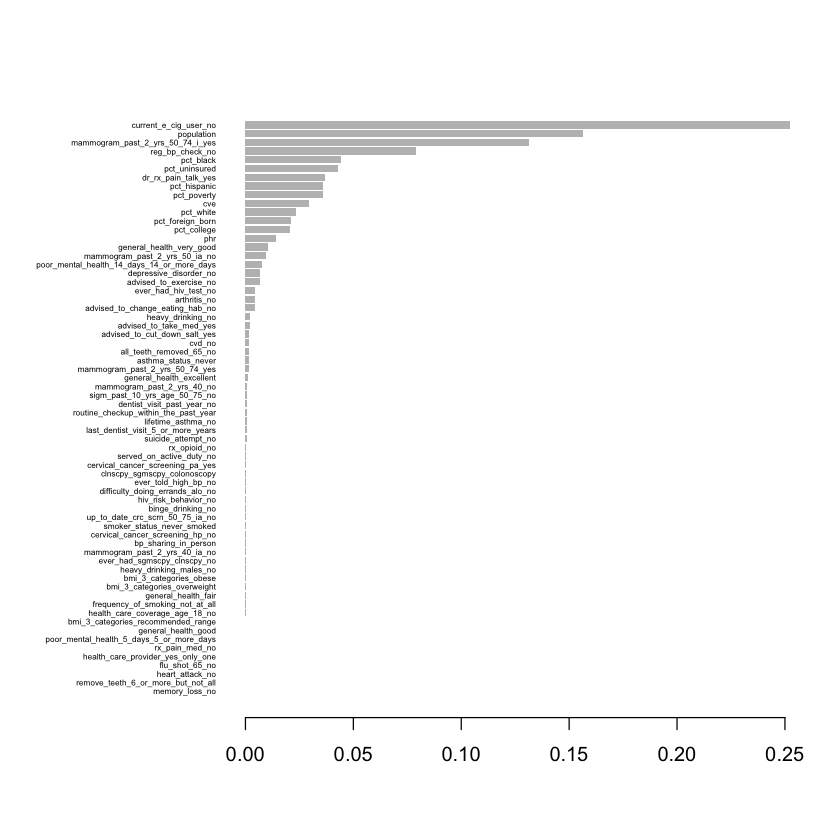

In [9]:
# boos: The algorithm draws a bootstrap sample of the training data in each iteration using the weights for each observation. 
# Misclassified or harder-to-predict samples receive higher weights, meaning they are 
# more likely to be selected for the next tree's training data

# mfinal: number of iterations

# TODO: add control bc it uses rpart each iteration
# Prepare matrices for xgb boost
X_train <- as.matrix(train_balanced[, names(train_balanced) != "outbreak"])
y_train <- as.numeric(as.character(train_balanced$outbreak))

X_test  <- as.matrix(train[, names(train) != "outbreak"])
y_test  <- as.numeric(as.character(train$outbreak))

dtrain  <- xgb.DMatrix(data = X_train, label = y_train)
dtest   <- xgb.DMatrix(data = X_test,  label = y_test)

boost_model <- xgb.train(
  params = list(
    objective   = "binary:logistic",
    eval_metric = "logloss",
    max_depth   = 3,
    eta         = 0.1
  ),
  data    = dtrain,
  nrounds = 500
)

pred <- as.factor(predict(boost_model, dtest)>=0.5)

boost_table <- table(Actual = as.factor(y_test), Predicted = pred)
boost_table

# importance graph
importance_matrix <- xgb.importance(model = boost_model)
xgb.plot.importance(importance_matrix)

This gives a quick comparison between the model accuracy

In [10]:
get_accuracy <- function(eval_table) {
  round(sum(diag(eval_table)) / sum(eval_table) * 100, 2)
}

results <- data.frame(
  Model    = c("Decision Tree (rpart)", "Random Forest", "XGBoost (softmax)"),
  Cutoff   = c("default", c, "default"),
  Accuracy = c(
    get_accuracy(dtree_table),
    get_accuracy(rforest_table),
    get_accuracy(boost_table)
  )
)

results$Best     <- ifelse(results$Accuracy == max(results$Accuracy), "<--", "")

print(results, row.names = FALSE)

                 Model  Cutoff Accuracy Best
 Decision Tree (rpart) default    90.10     
         Random Forest     0.4    91.15     
     XGBoost (softmax) default   100.00  <--


#### THIS SECTION IS FOR TUNED MODEL

We set some param for tuning the tree model here.

In [11]:
# classification tree related
FNlosses <- c(seq(1, 10, by=0.1))
cp0 <- -1
# random forest related
mtrys   <- c(seq(5, 50, by=5))
c_rf <- c(seq(0.2, 0.5, by=0.1))
# XGBoost related
c_xgb <- c(seq(0.2, 0.5, by=0.1)) # deciding what counts as outbreak
param_grid <- expand.grid( # tuning grid
  max_depth = c(seq(3, 9, by=2)),
  eta = c(0.01,seq(0.05, 0.4, by=0.05))
)

The following code block are set for auto select parameters for the classification tree model. We tune on penalty for false negative and the complexity parameter. We use 10 fold cross validation to select the best parameters.

In [12]:
set.seed(4)
folds <- createFolds(train_balanced$outbreak, k=10)

results <- data.frame()

for(j in 1:length(FNlosses)){
  fold_precision <- c()
  fold_recall    <- c()
  fold_accuracy  <- c()
  
  for(fold in folds){
    fold_train <- train_balanced[-fold, ]
    fold_test  <- train_balanced[fold, ]
    
    mod <- rpart(outbreak ~ .,
                 data   = fold_train,
                 method = "class",
                 parms  = list(loss=matrix(c(0,FNlosses[j],1,0), nrow=2)),
                 weights= ceiling(fold_train$population),
                 cp     = cp0) 
    
    cp_table <- mod$cptable
    opt_cp <- cp_table[which.min(cp_table[,"xerror"]), "CP"]
    pruned <- prune(mod, cp=opt_cp)
    
    preds <- predict(pruned, newdata=fold_test, type="class")
    cm    <- table(Actual=fold_test$outbreak, Predicted=preds)
    
    # precision = TP/(TP + FP)
    fold_precision <- c(fold_precision, cm[2,2]/sum(cm[,2]))
    # recall = TP/(TP + FN)
    fold_recall <- c(fold_recall, cm[2,2]/sum(cm[2,]))
    # accuracy = correct predictions/total
    fold_accuracy <- c(fold_accuracy, sum(diag(cm))/sum(cm))
  }
  
  results <- rbind(results, data.frame(
    FNloss = FNlosses[j],
    cp = opt_cp,
    precision = mean(fold_precision, na.rm=TRUE),
    recall = mean(fold_recall, na.rm=TRUE),
    accuracy = mean(fold_accuracy, na.rm=TRUE)
  ))
}

print(results)

   FNloss           cp precision    recall  accuracy
1     1.0 0.0000000000 0.8507596 0.8834559 0.8659537
2     1.1 0.0079662983 0.8414947 0.8959559 0.8628342
3     1.2 0.0000000000 0.8180997 0.8959559 0.8481283
4     1.3 0.0007530370 0.8326645 0.8886029 0.8566845
5     1.4 0.0000000000 0.8571370 0.9194853 0.8838681
6     1.5 0.0041056833 0.8368070 0.9319853 0.8745989
7     1.6 0.0000000000 0.8834477 0.9257353 0.9016043
8     1.7 0.0000000000 0.8645484 0.9194853 0.8896613
9     1.8 0.0027261325 0.8683185 0.9257353 0.8926916
10    1.9 0.0009636260 0.8687628 0.9253676 0.8897504
11    2.0 0.0023994038 0.8622860 0.9319853 0.8894831
12    2.1 0.0022852093 0.8768861 0.9444853 0.9045455
13    2.2 0.0021710147 0.8815605 0.9257353 0.9016043
14    2.3 0.0012565491 0.8679295 0.9191176 0.8867201
15    2.4 0.0013297799 0.8659245 0.9194853 0.8896613
16    2.5 0.0014030107 0.8738441 0.9257353 0.8955437
17    2.6 0.0014762414 0.8551724 0.9378676 0.8867201
18    2.7 0.0016000420 0.8607081 0.9444853 0.8

In [13]:
# Best by recall (tentatively)
best_clas <- results[which.max(results$recall), ]
print(best_clas)

   FNloss          cp precision    recall accuracy
22    3.1 0.001143264 0.8614235 0.9566176 0.901426


We then tune on random forest. We would tune on mtry and c. mtry is worth tuning in our case because there is a large set of correlated covariates.

In [14]:
set.seed(4)
folds <- createFolds(train_balanced$outbreak, k=10)

results_rf <- data.frame()

for(m in mtrys){
  for(c_val in c_rf){
    fold_precision <- c()
    fold_recall <- c()
    fold_accuracy <- c()
    
    for(fold in folds){
      fold_train <- train_balanced[-fold, ]
      fold_test  <- train_balanced[fold, ]
      
      rf <- randomForest(outbreak ~ .,
                         data   = fold_train,
                         mtry   = m,
                         ntree  = 500,
                         cutoff = c(c_val, 1-c_val))
      
      preds <- predict(rf, newdata = fold_test, type = "class")
      cm <- table(Actual=fold_test$outbreak, Predicted=preds)
      fold_precision <- c(fold_precision, cm[2,2] / sum(cm[,2]))
      fold_recall <- c(fold_recall, cm[2,2] / sum(cm[2,]))
      fold_accuracy <- c(fold_accuracy, sum(diag(cm)) / sum(cm))
    }
    
    results_rf <- rbind(results_rf, data.frame(
      mtry = m,
      cutoff = c_val,
      precision = mean(fold_precision, na.rm=TRUE),
      recall = mean(fold_recall, na.rm=TRUE),
      accuracy = mean(fold_accuracy, na.rm=TRUE)
    ))
  }
}

print(results_rf)

# Best by recall
best_rf <- results_rf[which.max(results_rf$recall), ]
print(best_rf)

   mtry cutoff precision    recall  accuracy
1     5    0.2 0.9191585 0.8702206 0.8983066
2     5    0.3 0.8868161 0.8889706 0.8893048
3     5    0.4 0.8722351 0.9073529 0.8892157
4     5    0.5 0.8735423 0.9136029 0.8922460
5    10    0.2 0.9534734 0.8580882 0.9103387
6    10    0.3 0.9331454 0.8952206 0.9159537
7    10    0.4 0.9013609 0.9136029 0.9071301
8    10    0.5 0.8781175 0.9198529 0.8983066
9    15    0.2 0.9740537 0.8643382 0.9221925
10   15    0.3 0.9498133 0.9011029 0.9280749
11   15    0.4 0.9385621 0.9073529 0.9249554
12   15    0.5 0.9052206 0.9198529 0.9131016
13   20    0.2 0.9740537 0.8518382 0.9163102
14   20    0.3 0.9629426 0.9073529 0.9369875
15   20    0.4 0.9509430 0.9198529 0.9370766
16   20    0.5 0.9342484 0.9316176 0.9338681
17   25    0.2 0.9734001 0.8397059 0.9104278
18   25    0.3 0.9740537 0.9073529 0.9428699
19   25    0.4 0.9568254 0.9257353 0.9429590
20   25    0.5 0.9391783 0.9316176 0.9370766
21   30    0.2 0.9735043 0.8397059 0.9103387
22   30   

We then tune for XGBoost.

In [ ]:
set.seed(4)
folds <- createFolds(train_balanced$outbreak, k=10)

results_xgb <- data.frame()

for(i in 1:nrow(param_grid)){
    fold_precision <- c()
    fold_recall <- c()
    fold_accuracy <- c()
    
    for(fold in folds){
      fold_train <- train_balanced[-fold, ]
      fold_test  <- train_balanced[fold, ]
      X_fold_train <- as.matrix(fold_train[, names(fold_train) != "outbreak"])
      y_fold_train <- as.numeric(as.character(fold_train$outbreak))
      X_fold_test  <- as.matrix(fold_test[, names(fold_test) != "outbreak"])
      y_fold_test  <- as.numeric(as.character(fold_test$outbreak))
      dtrain_fold  <- xgb.DMatrix(data = X_fold_train, label = y_fold_train)
      dtest_fold   <- xgb.DMatrix(data = X_fold_test,  label = y_fold_test)
      model <- xgb.train(
        params = list(
          objective   = "binary:logistic",
          eval_metric = "logloss",
          max_depth   = param_grid$max_depth[i],
          eta         = param_grid$eta[i]
        ),
        data    = dtrain_fold,
        nrounds = 500
      )
      
      for(c_val in c_xgb){
        # Adjust cutoff by modifying predictions
        preds <- as.numeric(predict(model, dtest_fold) >= c_val)
        cm <- table(Actual=fold_test$outbreak, Predicted=preds)
        fold_precision <- c(fold_precision, cm[2,2] / sum(cm[,2]))
        fold_recall <- c(fold_recall, cm[2,2] / sum(cm[2,]))
        fold_accuracy <- c(fold_accuracy, sum(diag(cm)) / sum(cm))

      }
      
    results_xgb <- rbind(results_xgb, data.frame(
      max_depth = param_grid$max_depth[i],
      eta = param_grid$eta[i],
      cutoff = c_val,
      precision = mean(fold_precision, na.rm=TRUE),
      precision_std = sd(fold_precision, na.rm=TRUE),
      recall = mean(fold_recall, na.rm=TRUE),
      accuracy = mean(fold_accuracy, na.rm=TRUE)
    ))
}
}
print(results_xgb)

# Best by recall
best_xgb <- results_xgb[which.max(results_xgb$recall), ]
print(best_xgb)

    max_depth  eta cutoff precision    recall  accuracy
1           3 0.01    0.5 0.8460526 0.9705882 0.8970588
2           3 0.01    0.5 0.9083204 0.9852941 0.9409537
3           3 0.01    0.5 0.9247191 0.9901961 0.9532828
4           3 0.01    0.5 0.9195810 0.9613971 0.9384470
5           3 0.01    0.5 0.9162602 0.9691176 0.9389929
6           3 0.01    0.5 0.9046965 0.9638480 0.9302213
7           3 0.01    0.5 0.9007675 0.9690126 0.9307359
8           3 0.01    0.5 0.9041846 0.9728860 0.9347984
9           3 0.01    0.5 0.9039375 0.9758987 0.9363240
10          3 0.01    0.5 0.9120732 0.9736213 0.9396613
11          5 0.01    0.5 0.8293651 0.9852941 0.8897059
12          5 0.01    0.5 0.9146825 0.9848346 0.9410651
13          5 0.01    0.5 0.9333178 0.9898897 0.9558081
14          5 0.01    0.5 0.9223842 0.9611673 0.9384470
15          5 0.01    0.5 0.9351296 0.9689338 0.9492870
16          5 0.01    0.5 0.9191138 0.9532782 0.9337493
17          5 0.01    0.5 0.9114543 0.9599527 0.

#### THIS SECTION IS FOR CREATING PARETO FRONTIER

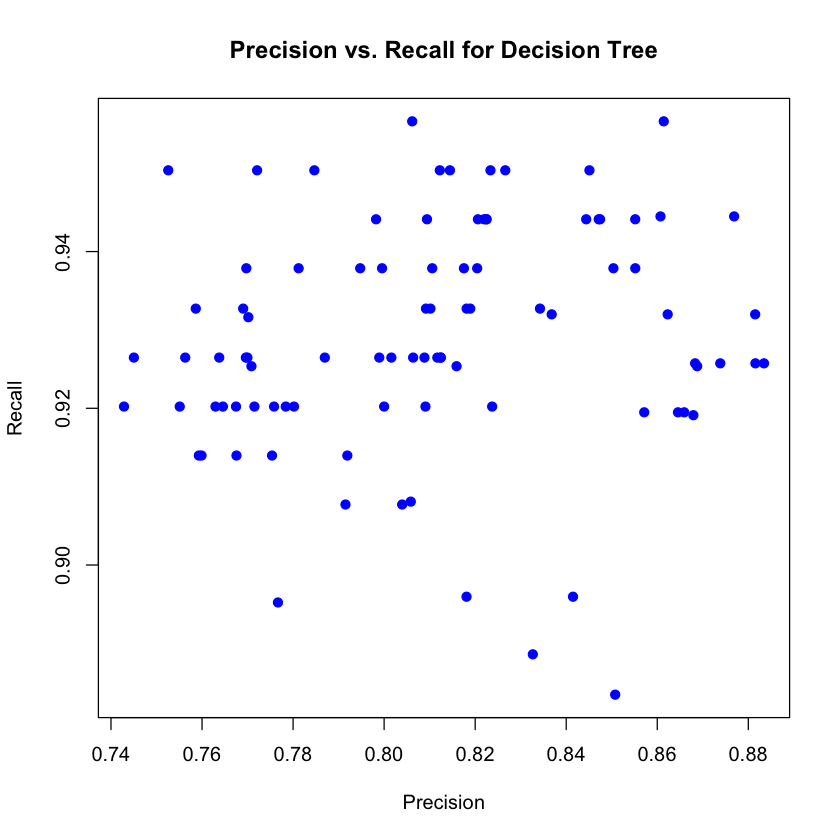

In [ ]:
x_axis <- results$precision
y_axis <- results$recall
# Basic Scatter Plot
plot(x_axis, y_axis, 
     main="Precision vs. Recall for Decision Tree", 
     xlab="Precision", 
     ylab="Recall", 
     pch=19, 
     col="blue")